# タイタニック号の生存予測：単体・多数決・確率アンサンブルとAD診断

## 対象者・前提・学習目標

**対象者**：Python・pandas・scikit-learnの基礎を学んだM1学生  
**前提**：分類、交差検証、F1スコアの基本を知っていること

このNotebookでは、配布された `train_titanic.csv` と `test_titanic.csv` **だけ**を使い、提出上限3件を次の構成で作ります。

1. **Hard voting**：RF・XGBoost・HistGradientBoostingの0/1予測を2票以上の多数決
2. **Weighted probability blend**：RF・XGBoost・HistGradientBoosting・Logistic Regressionの確率を混合
3. **XGBoost単体**：比較基準を兼ねる最良単体候補

さらにApplicability Domain（AD）をGower風距離で判定し、AD内外でモデルを切り替える仮説も検証します。ただし、学習データ内の評価で支持されなければ、面白さだけを理由に提出枠を使いません。

> **規約**：外部データ、既知のtest正解、Claude側成果物、LLM推論、人手によるラベル修正は使いません。testのAD比率は全設定を凍結した後に診断表示するだけで、モデル選定には使いません。

## このNotebookの流れ

1. 入力データと規約を検査する
2. 行単位特徴量と、fold内だけで学習する家族・Ticket特徴を作る
3. 4種類のモデルについて小さなハイパーパラメータ候補を比較する
4. train-only nested CVの結果から、提出する3方式を決める
5. 5分割 × 5乱数のOOFで最終設定・しきい値・blend重みを決める
6. AD内外の性能と不確実性を調べ、ADルータの採否を判断する
7. 全trainで再学習し、形式検査済みの提出CSVを3件作る

In [1]:
# 1. ライブラリと共通設定
from pathlib import Path
import itertools
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

CV_SEEDS = list(range(20260711, 20260716))
N_SPLITS = 5
TARGET_ALPHA = 5.0
THRESHOLD_GRID = np.round(np.arange(0.200, 0.6501, 0.005), 3)
HARD_VOTE_MODELS = ("random_forest", "xgboost", "hist_gradient_boosting")
BLEND_MODEL_ORDER = (
    "random_forest", "xgboost", "hist_gradient_boosting", "logistic_regression"
)
BLEND_WEIGHT_CANDIDATES = [
    (0.25, 0.25, 0.25, 0.25),
    (0.25, 0.35, 0.20, 0.20),
    (0.20, 0.40, 0.20, 0.20),
    (0.30, 0.40, 0.15, 0.15),
    (0.25, 0.45, 0.15, 0.15),
    (0.25, 0.40, 0.25, 0.10),
    (0.30, 0.35, 0.15, 0.20),
    (0.20, 0.45, 0.15, 0.20),
]
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#CC79A7"]

path_candidates = [Path.cwd(), Path.cwd() / "lesson_8" / "codex_code"]
PROJECT_DIR = next(
    (
        candidate
        for candidate in path_candidates
        if (candidate / "train_titanic.csv").exists()
        and (candidate / "test_titanic.csv").exists()
    ),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "train_titanic.csv と test_titanic.csv が見つかりません。"
        "codex_code またはリポジトリ直下から実行してください。"
    )
TRAIN_PATH = PROJECT_DIR / "train_titanic.csv"
TEST_PATH = PROJECT_DIR / "test_titanic.csv"
print(f"データディレクトリ: {PROJECT_DIR.name}")

データディレクトリ: codex_code


## 1. データを読み込み、契約を確認する

行数、列名、ID、目的変数を最初に検査します。ここで異常を止めると、列ずれや誤ったCSVを使ったまま学習する事故を防げます。

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

expected_train_columns = [
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
]
expected_test_columns = [column for column in expected_train_columns if column != "Survived"]

assert train.shape == (712, 12), f"trainの形が想定外です: {train.shape}"
assert test.shape == (179, 11), f"testの形が想定外です: {test.shape}"
assert train.columns.tolist() == expected_train_columns
assert test.columns.tolist() == expected_test_columns
assert train["Survived"].notna().all()
assert set(train["Survived"].unique()) == {0, 1}
assert train["PassengerId"].notna().all() and test["PassengerId"].notna().all()
assert train["PassengerId"].is_unique and test["PassengerId"].is_unique
assert set(train["PassengerId"]).isdisjoint(set(test["PassengerId"]))

X_raw = train.drop(columns="Survived").copy()
y = train["Survived"].astype("int64").copy()

print(f"train: {train.shape[0]}行 × {train.shape[1]}列")
print(f"test : {test.shape[0]}行 × {test.shape[1]}列")
display(train.head())

train: 712行 × 12列
test : 179行 × 11列


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
1,465,0,3,"Maisner, Mr. Simon",male,NaN,0,0,A/S 2816,8.0500,NaN,S
2,199,1,3,"Madigan, Miss. Margaret ""Maggie""",female,NaN,0,0,370370,7.7500,NaN,Q
3,766,1,1,"Hogeboom, Mrs. John C (Anna Andrews)",female,51.0000,1,0,13502,77.9583,D11,S
4,422,0,3,"Charters, Mr. David",male,21.0000,0,0,A/5. 13032,7.7333,NaN,Q


In [3]:
# 欠損値とラベル分布を小さな表で確認します。
missing_table = pd.DataFrame({
    "train_missing": train.drop(columns="Survived").isna().sum(),
    "test_missing": test.isna().sum(),
})
missing_table["train_rate"] = missing_table["train_missing"] / len(train)
missing_table["test_rate"] = missing_table["test_missing"] / len(test)

label_table = (
    y.value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .assign(rate=lambda frame: frame["count"] / len(y))
)

print("欠損がある列")
display(missing_table.loc[missing_table.sum(axis=1) > 0])
print("Survivedの分布")
display(label_table)

欠損がある列


,train_missing,test_missing,train_rate,test_rate
Age,146,31,0.2051,0.1732
Cabin,552,135,0.7753,0.7542
Embarked,2,0,0.0028,0.0000


Survivedの分布


,count,rate
Survived,,
0,439,0.6166
1,273,0.3834


**結果の見方**

- `Survived=1` は約38%で、完全な均衡データではありません。
- `Age`、`Cabin`、`Embarked` に欠損があります。
- 本番評価はAccuracyではなく、`Survived=1` を正例とする **F1スコア**です。
- testの欠損数は入力検査として表示するだけで、補完値・カテゴリ・モデル設定の学習には使いません。

## 2. 1行だけから作れる特徴量

次の特徴量は、他の乗客や正解ラベルを見ず、その行だけから作れます。

- `Title`：氏名から抽出した敬称
- `FamilySize` / `IsAlone`：同乗家族数と単独乗船フラグ
- `IsChild` / `IsMother`：年齢・敬称・家族関係から作る説明可能なフラグ
- `Deck` / `CabinKnown`：客室番号の先頭文字と欠損有無
- `TicketPrefix`：Ticketの数字以外の部分
- `FareLog` / `FarePerFamilyMember`：歪みを抑えた運賃と家族1人当たり運賃

`_FamilyKey` と `_TicketKey` は後でfold内統計を作るための内部キーです。モデルへ直接渡しません。

In [4]:
COMMON_TITLES = {"Mr", "Miss", "Mrs", "Master"}
TITLE_ALIASES = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}


def _alphanumeric_key(value: object, unknown: str = "__UNKNOWN__") -> str:
    """文字列を英数字の大文字へ正規化します。"""
    if pd.isna(value):
        return unknown
    normalized = re.sub(r"[^A-Z0-9]", "", str(value).upper())
    return normalized or unknown


def _extract_title(name: object) -> str:
    if pd.isna(name):
        return "Rare"
    match = re.search(r",\s*([^.]*)\.", str(name))
    title = match.group(1).strip() if match else "Rare"
    title = TITLE_ALIASES.get(title, title)
    return title if title in COMMON_TITLES else "Rare"


def _extract_ticket_prefix(ticket: object) -> str:
    if pd.isna(ticket):
        return "NONE"
    prefix = re.sub(r"[\d\W]+", "", str(ticket).upper())
    return prefix or "NONE"


def make_row_features(frame: pd.DataFrame) -> pd.DataFrame:
    """他の行を参照せずに作れる特徴量だけを返します。"""
    result = pd.DataFrame(index=frame.index)

    title = frame["Name"].map(_extract_title)
    surname = frame["Name"].str.split(",", n=1).str[0].map(_alphanumeric_key)
    family_size = (frame["SibSp"] + frame["Parch"] + 1).astype("int64")
    age = frame["Age"]
    fare = frame["Fare"]

    # 元の基本列
    result["Pclass"] = frame["Pclass"].astype(str)
    result["Sex"] = frame["Sex"].astype("object")
    result["Age"] = age
    result["SibSp"] = frame["SibSp"]
    result["Parch"] = frame["Parch"]
    result["Fare"] = fare
    result["Embarked"] = frame["Embarked"].astype("object")

    # 氏名・家族
    result["Title"] = title
    result["NameLength"] = frame["Name"].fillna("").str.len()
    result["FamilySize"] = family_size
    result["IsAlone"] = (family_size == 1).astype("int64")
    result["FamilySizeBand"] = np.select(
        [family_size.eq(1), family_size.le(4)],
        ["Solo", "Small"],
        default="Large",
    )
    result["IsChild"] = ((age < 16) | title.eq("Master")).astype("int64")
    result["IsMother"] = (
        frame["Sex"].eq("female")
        & frame["Parch"].gt(0)
        & title.ne("Miss")
        & (age.gt(18) | age.isna())
    ).astype("int64")

    # 年齢
    result["AgeMissing"] = age.isna().astype("int64")
    age_band = np.select(
        [age.lt(13), age.lt(18), age.lt(35), age.lt(60)],
        ["Child", "Teen", "YoungAdult", "Adult"],
        default="Senior",
    )
    result["AgeBand"] = pd.Series(age_band, index=frame.index).where(
        age.notna(), "Unknown"
    )

    # Ticket
    result["TicketPrefix"] = frame["Ticket"].map(_extract_ticket_prefix)
    result["TicketNumberLength"] = (
        frame["Ticket"].fillna("").str.count(r"\d").astype("int64")
    )

    # Cabin
    cabin_text = frame["Cabin"].fillna("").astype(str)
    result["CabinKnown"] = frame["Cabin"].notna().astype("int64")
    result["CabinCount"] = cabin_text.map(lambda value: len(value.split()) if value else 0)
    result["Deck"] = cabin_text.str[:1].replace("", "Unknown")

    # 運賃
    result["FareLog"] = np.log1p(fare.clip(lower=0))
    result["FarePerFamilyMember"] = fare / family_size.clip(lower=1)

    # 木モデルが使いやすい交互作用カテゴリ
    result["SexPclass"] = frame["Sex"].astype(str) + "_P" + frame["Pclass"].astype(str)
    result["TitlePclass"] = title.astype(str) + "_P" + frame["Pclass"].astype(str)

    # fold内統計専用。単独乗船者を同じ家族として扱わないようにします。
    family_key = surname + "_" + family_size.astype(str)
    result["_FamilyKey"] = family_key.where(family_size.gt(1), "__SINGLE__")
    result["_TicketKey"] = frame["Ticket"].map(_alphanumeric_key)

    assert result.index.equals(frame.index)
    return result


base_train = make_row_features(X_raw)
base_test = make_row_features(test)
print(f"行単位特徴量: {base_train.shape[1]}列")
display(base_train.head())

行単位特徴量: 27列


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,NameLength,FamilySize,IsAlone,FamilySizeBand,IsChild,IsMother,AgeMissing,AgeBand,TicketPrefix,TicketNumberLength,CabinKnown,CabinCount,Deck,FareLog,FarePerFamilyMember,SexPclass,TitlePclass,_FamilyKey,_TicketKey
0,3,female,NaN,0,0,7.6292,Q,Miss,30,1,1,Solo,0,0,1,Unknown,NONE,6,0,0,Unknown,2.1552,7.6292,female_P3,Miss_P3,__SINGLE__,330909
1,3,male,NaN,0,0,8.0500,S,Mr,18,1,1,Solo,0,0,1,Unknown,AS,4,0,0,Unknown,2.2028,8.0500,male_P3,Mr_P3,__SINGLE__,AS2816
2,3,female,NaN,0,0,7.7500,Q,Miss,32,1,1,Solo,0,0,1,Unknown,NONE,6,0,0,Unknown,2.1691,7.7500,female_P3,Miss_P3,__SINGLE__,370370
3,1,female,51.0000,1,0,77.9583,S,Mrs,36,2,0,Small,0,0,0,Adult,NONE,5,1,1,D,4.3689,38.9791,female_P1,Mrs_P1,HOGEBOOM_2,13502
4,3,male,21.0000,0,0,7.7333,Q,Mr,19,1,1,Solo,0,0,0,YoungAdult,A,6,0,0,Unknown,2.1671,7.7333,male_P3,Mr_P3,__SINGLE__,A513032


## 3. 家族・Ticketの統計特徴をリークなしで作る

同じ家族やTicketの乗客は、避難行動が似る可能性があります。そこで次を追加します。

- 学習fold内にいる同行者数
- 同行者の平滑化生存率

ただし、学習行自身のラベルをグループ和へ残すと即座にリークします。グループ $g$ に属する学習行 $i$ は

$$
\mathrm{TE}_i = \frac{(S_g-y_i)+\alpha\mu}{(N_g-1)+\alpha},
\qquad
\mu=\frac{T}{n}
$$

とします。グループの和・件数から自分を除き、事前確率 $\mu$ はfold内で全行共通の定数にします。$\mu_{-i}=(T-y_i)/(n-1)$ のように行ごとに変えると、木モデルがその微小な2値差から自己ラベルを逆算できるため使いません。

検証・testでは、**学習foldだけ**の和・件数・全体率を使います。`alpha=5` は小さいグループを全体率へ戻す平滑化です。

In [5]:
GROUP_SPECS = {
    "_FamilyKey": {
        "invalid": "__SINGLE__",
        "count_column": "FamilyPeerCount",
        "rate_column": "FamilySurvivalTE",
    },
    "_TicketKey": {
        "invalid": "__UNKNOWN__",
        "count_column": "TicketPeerCount",
        "rate_column": "TicketSurvivalTE",
    },
}


def fit_group_state(
    fit_features: pd.DataFrame,
    fit_target: pd.Series | np.ndarray,
    alpha: float = TARGET_ALPHA,
) -> dict:
    """fit側だけからグループ統計を学習します。"""
    target = np.asarray(fit_target, dtype=float)
    if len(fit_features) != len(target):
        raise ValueError("特徴量と目的変数の行数が一致しません。")
    if len(target) < 2:
        raise ValueError("leave-one-outには2行以上必要です。")

    state = {
        "alpha": float(alpha),
        "n_rows": len(target),
        "target_sum": float(target.sum()),
        "prior": float(target.mean()),
        "groups": {},
    }

    for key_column, spec in GROUP_SPECS.items():
        keys = fit_features[key_column].astype(str).to_numpy()
        valid = keys != spec["invalid"]
        work = pd.DataFrame({"key": keys[valid], "target": target[valid]})
        stats = work.groupby("key", sort=False)["target"].agg(["sum", "count"])
        state["groups"][key_column] = stats

    return state


def augment_train_loo(
    fit_features: pd.DataFrame,
    fit_target: pd.Series | np.ndarray,
    state: dict,
) -> pd.DataFrame:
    """学習行へ、グループ和から自分を除いた統計特徴を追加します。"""
    target = np.asarray(fit_target, dtype=float)
    if len(fit_features) != state["n_rows"] or len(target) != state["n_rows"]:
        raise ValueError("stateを学習したデータと行数が一致しません。")

    result = fit_features.copy()
    alpha = state["alpha"]
    # fold内で全行共通のpriorを使い、ラベルごとの微小な指紋を作りません。
    loo_prior = np.full(len(target), state["prior"], dtype=float)

    for key_column, spec in GROUP_SPECS.items():
        keys = result[key_column].astype(str).to_numpy()
        valid = keys != spec["invalid"]
        stats = state["groups"][key_column]
        mapped_sum = pd.Series(keys).map(stats["sum"]).to_numpy(dtype=float)
        mapped_count = pd.Series(keys).map(stats["count"]).to_numpy(dtype=float)
        seen = np.isfinite(mapped_count)

        peer_count = np.where(valid & seen, mapped_count - 1.0, 0.0)
        numerator = np.nan_to_num(mapped_sum, nan=0.0) - target + alpha * loo_prior
        denominator = np.maximum(peer_count, 0.0) + alpha
        rate = numerator / denominator
        rate = np.where(valid & seen, rate, loo_prior)

        result[spec["count_column"]] = peer_count.astype(float)
        result[spec["rate_column"]] = rate.astype(float)

    rate_columns = [spec["rate_column"] for spec in GROUP_SPECS.values()]
    assert result[rate_columns].notna().all().all()
    assert ((result[rate_columns] >= 0) & (result[rate_columns] <= 1)).all().all()
    assert result.index.equals(fit_features.index)
    return result


def augment_inference(inference_features: pd.DataFrame, state: dict) -> pd.DataFrame:
    """検証・testへ、fit側だけで作った統計特徴を追加します。"""
    result = inference_features.copy()
    alpha = state["alpha"]
    prior = state["prior"]

    for key_column, spec in GROUP_SPECS.items():
        keys = result[key_column].astype(str).to_numpy()
        valid = keys != spec["invalid"]
        stats = state["groups"][key_column]
        mapped_sum = pd.Series(keys).map(stats["sum"]).to_numpy(dtype=float)
        mapped_count = pd.Series(keys).map(stats["count"]).to_numpy(dtype=float)
        seen = np.isfinite(mapped_count)

        peer_count = np.where(valid & seen, mapped_count, 0.0)
        numerator = np.nan_to_num(mapped_sum, nan=0.0) + alpha * prior
        denominator = np.nan_to_num(mapped_count, nan=0.0) + alpha
        rate = numerator / denominator
        rate = np.where(valid & seen, rate, prior)

        result[spec["count_column"]] = peer_count.astype(float)
        result[spec["rate_column"]] = rate.astype(float)

    rate_columns = [spec["rate_column"] for spec in GROUP_SPECS.values()]
    assert result[rate_columns].notna().all().all()
    assert ((result[rate_columns] >= 0) & (result[rate_columns] <= 1)).all().all()
    assert result.index.equals(inference_features.index)
    return result

In [6]:
# leave-one-outの式を小さな人工データで単体テストします。
toy_features = pd.DataFrame({
    "_FamilyKey": ["FAMILY_A", "FAMILY_A", "FAMILY_B"],
    "_TicketKey": ["TICKET_A", "TICKET_A", "TICKET_B"],
})
toy_target = np.array([1, 0, 1])

toy_state = fit_group_state(toy_features, toy_target)
toy_train_encoded = augment_train_loo(toy_features, toy_target, toy_state)
toy_prior = toy_target.mean()

# FAMILY_Aの各行は、自分ではなく相手のラベルだけをグループ和に使います。
expected_row_0 = (0 + TARGET_ALPHA * toy_prior) / (1 + TARGET_ALPHA)
expected_row_1 = (1 + TARGET_ALPHA * toy_prior) / (1 + TARGET_ALPHA)
assert np.isclose(toy_train_encoded.iloc[0]["FamilySurvivalTE"], expected_row_0)
assert np.isclose(toy_train_encoded.iloc[1]["FamilySurvivalTE"], expected_row_1)

# 同行者がいない学習行と、未知グループの推論行はfold共通priorへ戻ります。
assert np.isclose(toy_train_encoded.iloc[2]["FamilySurvivalTE"], toy_prior)
toy_unknown = pd.DataFrame({
    "_FamilyKey": ["NEW_FAMILY"],
    "_TicketKey": ["NEW_TICKET"],
})
toy_unknown_encoded = augment_inference(toy_unknown, toy_state)
assert np.isclose(toy_unknown_encoded.iloc[0]["FamilySurvivalTE"], toy_prior)
assert np.isclose(toy_unknown_encoded.iloc[0]["TicketSurvivalTE"], toy_prior)

# priorが全学習行で共通であり、目的変数ごとの2値特徴にならないことも確認します。
singletons = pd.DataFrame({
    "_FamilyKey": ["__SINGLE__"] * 4,
    "_TicketKey": ["A", "B", "C", "D"],
})
singleton_target = np.array([0, 1, 0, 1])
singleton_state = fit_group_state(singletons, singleton_target)
singleton_encoded = augment_train_loo(singletons, singleton_target, singleton_state)
assert singleton_encoded["FamilySurvivalTE"].nunique() == 1
assert np.isclose(singleton_encoded["FamilySurvivalTE"].iloc[0], singleton_target.mean())
print("LOO target encodingの単体テスト: OK")

LOO target encodingの単体テスト: OK


## 4. 候補モデルとハイパーパラメータ

小標本の表形式データで性質が異なる4 familyを比較します。

- **Random Forest**：bootstrap標本上の決定木を平均するbagging
- **XGBoost**：誤差を順に改善する正則化boosting
- **HistGradientBoosting**：数値をbin化して学習するscikit-learnのboosting
- **Logistic Regression**：正則化された線形モデル。木モデルと異なる誤りを期待

候補数を各3件に限定し、際限のない探索による過適合を抑えます。数値列はfold内で中央値補完・標準化、カテゴリ列はfold内で最頻値補完・One-hot encodingします。木モデルは単調変換に不変なので、共通の前処理を使えます。

In [7]:
NUMERIC_COLUMNS = [
    "Age", "SibSp", "Parch", "Fare", "NameLength", "FamilySize",
    "IsAlone", "IsChild", "IsMother", "AgeMissing",
    "TicketNumberLength", "CabinKnown", "CabinCount",
    "FareLog", "FarePerFamilyMember", "FamilyPeerCount", "TicketPeerCount",
    "FamilySurvivalTE", "TicketSurvivalTE",
]
CATEGORICAL_COLUMNS = [
    "Pclass", "Sex", "Embarked", "Title", "FamilySizeBand", "AgeBand",
    "TicketPrefix", "Deck", "SexPclass", "TitlePclass",
]
MODEL_COLUMNS = NUMERIC_COLUMNS + CATEGORICAL_COLUMNS
FORBIDDEN_MODEL_COLUMNS = {
    "PassengerId", "Survived", "Name", "Ticket", "Cabin",
    "_FamilyKey", "_TicketKey",
}
assert FORBIDDEN_MODEL_COLUMNS.isdisjoint(MODEL_COLUMNS)


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=2,
                sparse_output=False,
                dtype=np.float32,
            ),
        ),
    ])
    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, NUMERIC_COLUMNS),
            ("categorical", categorical_pipeline, CATEGORICAL_COLUMNS),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


MODEL_CONFIGS = {
    "random_forest": [
        {
            "name": "rf_current", "n_estimators": 400, "max_depth": 7,
            "min_samples_leaf": 2, "max_features": 0.5, "class_weight": None,
        },
        {
            "name": "rf_shallow", "n_estimators": 500, "max_depth": 6,
            "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": None,
        },
        {
            "name": "rf_balanced", "n_estimators": 500, "max_depth": 8,
            "min_samples_leaf": 3, "max_features": 0.7,
            "class_weight": "balanced_subsample",
        },
    ],
    "xgboost": [
        {
            "name": "xgb_current", "n_estimators": 400,
            "learning_rate": 0.025, "max_depth": 3, "min_child_weight": 3,
            "subsample": 0.85, "colsample_bytree": 0.85,
            "reg_alpha": 0.05, "reg_lambda": 5.0,
        },
        {
            "name": "xgb_less_regularized", "n_estimators": 500,
            "learning_rate": 0.025, "max_depth": 3, "min_child_weight": 2,
            "subsample": 0.90, "colsample_bytree": 0.90,
            "reg_alpha": 0.05, "reg_lambda": 4.0,
        },
        {
            "name": "xgb_shallow", "n_estimators": 450,
            "learning_rate": 0.030, "max_depth": 2, "min_child_weight": 1,
            "subsample": 0.90, "colsample_bytree": 0.90,
            "reg_alpha": 0.00, "reg_lambda": 4.0,
        },
    ],
    "hist_gradient_boosting": [
        {
            "name": "hgb_small", "max_iter": 250, "learning_rate": 0.05,
            "max_leaf_nodes": 15, "min_samples_leaf": 20,
            "l2_regularization": 3.0,
        },
        {
            "name": "hgb_medium", "max_iter": 300, "learning_rate": 0.04,
            "max_leaf_nodes": 31, "min_samples_leaf": 15,
            "l2_regularization": 5.0,
        },
        {
            "name": "hgb_compact", "max_iter": 250, "learning_rate": 0.05,
            "max_leaf_nodes": 7, "min_samples_leaf": 12,
            "l2_regularization": 2.0,
        },
    ],
    "logistic_regression": [
        {"name": "logit_c0.10", "C": 0.10},
        {"name": "logit_c0.30", "C": 0.30},
        {"name": "logit_c1.00", "C": 1.00},
    ],
}

MODEL_DISPLAY_NAMES = {
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
    "hist_gradient_boosting": "HistGradientBoosting",
    "logistic_regression": "Logistic Regression",
}


def build_model(model_name: str, config: dict, random_state: int):
    params = {key: value for key, value in config.items() if key != "name"}
    if model_name == "random_forest":
        return RandomForestClassifier(random_state=random_state, n_jobs=-1, **params)
    if model_name == "xgboost":
        return XGBClassifier(
            objective="binary:logistic", eval_metric="logloss", tree_method="hist",
            random_state=random_state, n_jobs=-1, verbosity=0, **params,
        )
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(random_state=random_state, **params)
    if model_name == "logistic_regression":
        return LogisticRegression(
            solver="lbfgs", max_iter=3000, random_state=random_state, **params
        )
    raise KeyError(model_name)


config_rows = []
for model_name, configs in MODEL_CONFIGS.items():
    for config in configs:
        config_rows.append({
            "model": MODEL_DISPLAY_NAMES[model_name],
            "config": config["name"],
            "parameters": str({k: v for k, v in config.items() if k != "name"}),
        })
display(pd.DataFrame(config_rows))

,model,config,parameters
0,Random Forest,rf_current,"{'n_estimators': 400, 'max_depth': 7, 'min_sam..."
1,Random Forest,rf_shallow,"{'n_estimators': 500, 'max_depth': 6, 'min_sam..."
2,Random Forest,rf_balanced,"{'n_estimators': 500, 'max_depth': 8, 'min_sam..."
3,XGBoost,xgb_current,"{'n_estimators': 400, 'learning_rate': 0.025, ..."
4,XGBoost,xgb_less_regularized,"{'n_estimators': 500, 'learning_rate': 0.025, ..."
5,XGBoost,xgb_shallow,"{'n_estimators': 450, 'learning_rate': 0.03, '..."
6,HistGradientBoosting,hgb_small,"{'max_iter': 250, 'learning_rate': 0.05, 'max_..."
7,HistGradientBoosting,hgb_medium,"{'max_iter': 300, 'learning_rate': 0.04, 'max_..."
8,HistGradientBoosting,hgb_compact,"{'max_iter': 250, 'learning_rate': 0.05, 'max_..."
9,Logistic Regression,logit_c0.10,{'C': 0.1}


## 5. train-only nested CVによる提出方式の選定

ハイパーパラメータ・しきい値・多数決・blend重みをinner 4-foldだけで選び、outer 5-foldを評価専用にするnested CVを2反復しました。各反復では5つのouter予測をPassengerId順に連結し、712人全体で1つのF1を計算しています。

同じ712人を分割し直した2値なので、独立実験 `n=2` や有意差とは解釈しません。数値は**分割感度を伴う記述的な選定根拠**です。

In [8]:
# このセルは方式選定の根拠を完全再現するため、約5分かかります。
NESTED_OUTER_SEEDS = CV_SEEDS[:2]
NESTED_OUTER_SPLITS = 5
NESTED_INNER_SPLITS = 4
NESTED_THRESHOLD_GRID = np.round(np.arange(0.25, 0.651, 0.01), 2)
NESTED_BLEND_THRESHOLD_GRID = np.round(np.arange(0.30, 0.601, 0.01), 2)


def nested_labels_from_probability(probability: np.ndarray, threshold: float) -> np.ndarray:
    return (np.asarray(probability) >= threshold).astype("int64")


def nested_score_labels(target: np.ndarray, labels: np.ndarray) -> tuple[float, float, float]:
    return (
        float(f1_score(target, labels, zero_division=0)),
        float(precision_score(target, labels, zero_division=0)),
        float(recall_score(target, labels, zero_division=0)),
    )


def nested_choose_config(target: np.ndarray, probabilities: list[np.ndarray]) -> dict:
    best = None
    for config_index, probability in enumerate(probabilities):
        for threshold in NESTED_THRESHOLD_GRID:
            labels = nested_labels_from_probability(probability, threshold)
            f1, precision, recall = nested_score_labels(target, labels)
            key = (-f1, abs(float(threshold) - 0.5), config_index, float(threshold))
            if best is None or key < best[0]:
                best = (key, config_index, float(threshold), f1, precision, recall)
    return {
        "config_index": best[1], "threshold": best[2],
        "inner_f1": best[3], "inner_precision": best[4], "inner_recall": best[5],
    }


def nested_threshold_neighbors(center: float) -> list[float]:
    return sorted({
        float(np.clip(round(center + offset, 2), 0.20, 0.70))
        for offset in (-0.04, 0.0, 0.04)
    })


def nested_choose_hard_vote(
    target: np.ndarray,
    probabilities: dict[str, np.ndarray],
    selected: dict,
    model_names: tuple[str, str, str],
) -> dict:
    best = None
    for thresholds in itertools.product(
        *(nested_threshold_neighbors(selected[name]["threshold"]) for name in model_names)
    ):
        votes = sum(
            nested_labels_from_probability(probabilities[name], threshold)
            for name, threshold in zip(model_names, thresholds)
        )
        labels = (votes >= 2).astype("int64")
        f1, precision, recall = nested_score_labels(target, labels)
        key = (
            -f1,
            sum(abs(threshold - 0.5) for threshold in thresholds),
            thresholds,
        )
        if best is None or key < best[0]:
            best = (key, thresholds, f1, precision, recall)
    return {
        "models": model_names,
        "thresholds": dict(zip(model_names, best[1])),
        "inner_f1": best[2], "inner_precision": best[3], "inner_recall": best[4],
    }


def nested_choose_blend(target: np.ndarray, probabilities: dict[str, np.ndarray]) -> dict:
    best = None
    for weights in BLEND_WEIGHT_CANDIDATES:
        blended = sum(
            weight * probabilities[model_name]
            for model_name, weight in zip(BLEND_MODEL_ORDER, weights)
        )
        for threshold in NESTED_BLEND_THRESHOLD_GRID:
            labels = nested_labels_from_probability(blended, threshold)
            f1, precision, recall = nested_score_labels(target, labels)
            key = (
                -f1,
                abs(float(threshold) - 0.5),
                sum(abs(weight - 0.25) for weight in weights),
                weights,
            )
            if best is None or key < best[0]:
                best = (key, weights, float(threshold), f1, precision, recall)
    return {
        "weights": dict(zip(BLEND_MODEL_ORDER, best[1])),
        "threshold": best[2],
        "inner_f1": best[3], "inner_precision": best[4], "inner_recall": best[5],
    }


def prepare_nested_fold(
    fit_indices: np.ndarray, valid_indices: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    fit_base = base_train.iloc[fit_indices].copy()
    valid_base = base_train.iloc[valid_indices].copy()
    fit_target = y.iloc[fit_indices].to_numpy()
    group_state = fit_group_state(fit_base, fit_target)
    fit_features = augment_train_loo(fit_base, fit_target, group_state)
    valid_features = augment_inference(valid_base, group_state)
    preprocessor = build_preprocessor()
    transformed_fit = preprocessor.fit_transform(fit_features[MODEL_COLUMNS])
    transformed_valid = preprocessor.transform(valid_features[MODEL_COLUMNS])
    assert np.isfinite(transformed_fit).all()
    assert np.isfinite(transformed_valid).all()
    return transformed_fit, transformed_valid, fit_target


def run_nested_benchmark() -> tuple[pd.DataFrame, pd.DataFrame, list[dict], dict]:
    y_array = y.to_numpy()
    method_names = [
        "Weighted blend (RF + XGB + HGB + Logit)",
        "Hard vote (RF + XGB + HGB)",
        "XGBoost single",
        "Hard vote (RF + XGB + Logit)",
    ]
    repeat_metrics = []
    outer_records = []
    predictions_by_repeat = {}

    for repeat_index, outer_seed in enumerate(NESTED_OUTER_SEEDS):
        repeat_prediction = {
            method_name: np.full(len(y), -1, dtype="int64")
            for method_name in method_names
        }
        coverage = np.zeros(len(y), dtype="int64")
        outer_splitter = StratifiedKFold(
            n_splits=NESTED_OUTER_SPLITS, shuffle=True, random_state=outer_seed
        )

        for outer_fold, (outer_fit, outer_valid) in enumerate(
            outer_splitter.split(base_train, y), start=1
        ):
            coverage[outer_valid] += 1
            inner_target = y_array[outer_fit]
            inner_probabilities = {
                model_name: [
                    np.zeros(len(outer_fit), dtype=float) for _ in configs
                ]
                for model_name, configs in MODEL_CONFIGS.items()
            }
            inner_coverage = np.zeros(len(outer_fit), dtype="int64")
            inner_seed = outer_seed + outer_fold * 1000
            inner_splitter = StratifiedKFold(
                n_splits=NESTED_INNER_SPLITS, shuffle=True, random_state=inner_seed
            )

            for inner_fold, (inner_fit_local, inner_valid_local) in enumerate(
                inner_splitter.split(np.arange(len(outer_fit)), inner_target), start=1
            ):
                inner_coverage[inner_valid_local] += 1
                inner_fit_global = outer_fit[inner_fit_local]
                inner_valid_global = outer_fit[inner_valid_local]
                transformed_fit, transformed_valid, y_inner_fit = prepare_nested_fold(
                    inner_fit_global, inner_valid_global
                )
                model_seed = inner_seed + inner_fold * 100
                for model_name, configs in MODEL_CONFIGS.items():
                    for config_index, config in enumerate(configs):
                        model = build_model(model_name, config, model_seed)
                        model.fit(transformed_fit, y_inner_fit)
                        inner_probabilities[model_name][config_index][inner_valid_local] = (
                            model.predict_proba(transformed_valid)[:, 1]
                        )

            assert np.all(inner_coverage == 1)
            selected = {
                model_name: nested_choose_config(inner_target, probabilities)
                for model_name, probabilities in inner_probabilities.items()
            }
            selected_probability = {}
            for model_name, choice in selected.items():
                config_index = choice["config_index"]
                choice["config_name"] = MODEL_CONFIGS[model_name][config_index]["name"]
                selected_probability[model_name] = inner_probabilities[model_name][config_index]

            hard_hgb = nested_choose_hard_vote(
                inner_target,
                selected_probability,
                selected,
                ("random_forest", "xgboost", "hist_gradient_boosting"),
            )
            hard_logit = nested_choose_hard_vote(
                inner_target,
                selected_probability,
                selected,
                ("random_forest", "xgboost", "logistic_regression"),
            )
            blend = nested_choose_blend(inner_target, selected_probability)

            transformed_outer_fit, transformed_outer_valid, y_outer_fit = prepare_nested_fold(
                outer_fit, outer_valid
            )
            outer_probability = {}
            outer_model_seed = outer_seed + outer_fold * 10_000
            for model_name, choice in selected.items():
                config = MODEL_CONFIGS[model_name][choice["config_index"]]
                model = build_model(model_name, config, outer_model_seed)
                model.fit(transformed_outer_fit, y_outer_fit)
                outer_probability[model_name] = model.predict_proba(
                    transformed_outer_valid
                )[:, 1]

            repeat_prediction["XGBoost single"][outer_valid] = nested_labels_from_probability(
                outer_probability["xgboost"], selected["xgboost"]["threshold"]
            )
            for method_name, hard_choice in [
                ("Hard vote (RF + XGB + HGB)", hard_hgb),
                ("Hard vote (RF + XGB + Logit)", hard_logit),
            ]:
                votes = sum(
                    nested_labels_from_probability(
                        outer_probability[model_name],
                        hard_choice["thresholds"][model_name],
                    )
                    for model_name in hard_choice["models"]
                )
                repeat_prediction[method_name][outer_valid] = (votes >= 2).astype("int64")

            blended_outer_probability = sum(
                blend["weights"][model_name] * outer_probability[model_name]
                for model_name in BLEND_MODEL_ORDER
            )
            repeat_prediction["Weighted blend (RF + XGB + HGB + Logit)"][outer_valid] = (
                nested_labels_from_probability(blended_outer_probability, blend["threshold"])
            )

            outer_records.append({
                "repeat": repeat_index,
                "outer_seed": outer_seed,
                "outer_fold": outer_fold,
                "fit_size": len(outer_fit),
                "valid_size": len(outer_valid),
                "selected_configs": {
                    model_name: choice["config_name"]
                    for model_name, choice in selected.items()
                },
                "selected_thresholds": {
                    model_name: choice["threshold"]
                    for model_name, choice in selected.items()
                },
                "hard_hgb_thresholds": hard_hgb["thresholds"],
                "hard_logit_thresholds": hard_logit["thresholds"],
                "blend_weights": blend["weights"],
                "blend_threshold": blend["threshold"],
            })
            print(
                f"Nested repeat {repeat_index + 1}/{len(NESTED_OUTER_SEEDS)}, "
                f"outer fold {outer_fold}/{NESTED_OUTER_SPLITS}: 完了"
            )

        assert np.all(coverage == 1)
        for method_name, prediction in repeat_prediction.items():
            assert (prediction >= 0).all()
            repeat_metrics.append({
                "repeat": repeat_index,
                "method": method_name,
                "f1": f1_score(y_array, prediction),
                "precision": precision_score(y_array, prediction, zero_division=0),
                "recall": recall_score(y_array, prediction, zero_division=0),
                "predicted_positive": int(prediction.sum()),
            })
        predictions_by_repeat[repeat_index] = repeat_prediction

    repeat_table = pd.DataFrame(repeat_metrics)
    summary = (
        repeat_table.groupby("method", as_index=False)
        .agg(
            f1_mean=("f1", "mean"),
            f1_split_sd=("f1", "std"),
            precision_mean=("precision", "mean"),
            recall_mean=("recall", "mean"),
        )
        .sort_values("f1_mean", ascending=False)
        .reset_index(drop=True)
    )

    record_frame = pd.DataFrame(outer_records)
    selection_rows = []
    for model_name in MODEL_CONFIGS:
        counts = pd.Series([
            record["selected_configs"][model_name] for record in outer_records
        ]).value_counts()
        selection_rows.append({
            "family": MODEL_DISPLAY_NAMES[model_name],
            "most_selected": counts.index[0],
            "count": f"{counts.iloc[0]} / {len(outer_records)}",
        })
    blend_counts = pd.Series([
        str(tuple(record["blend_weights"][name] for name in BLEND_MODEL_ORDER))
        for record in outer_records
    ]).value_counts()
    selection_rows.append({
        "family": "Blend weights",
        "most_selected": blend_counts.index[0],
        "count": f"{blend_counts.iloc[0]} / {len(outer_records)}",
    })
    selection_table = pd.DataFrame(selection_rows)
    return summary, selection_table, outer_records, predictions_by_repeat


nested_summary, nested_selection_frequency, nested_outer_records, nested_predictions = (
    run_nested_benchmark()
)
display(nested_summary.round(4))
display(nested_selection_frequency)

Nested repeat 1/2, outer fold 1/5: 完了
Nested repeat 1/2, outer fold 2/5: 完了
Nested repeat 1/2, outer fold 3/5: 完了
Nested repeat 1/2, outer fold 4/5: 完了
Nested repeat 1/2, outer fold 5/5: 完了
Nested repeat 2/2, outer fold 1/5: 完了
Nested repeat 2/2, outer fold 2/5: 完了
Nested repeat 2/2, outer fold 3/5: 完了
Nested repeat 2/2, outer fold 4/5: 完了
Nested repeat 2/2, outer fold 5/5: 完了


,method,f1_mean,f1_split_sd,precision_mean,recall_mean
0,Hard vote (RF + XGB + HGB),0.7908,0.0101,0.7601,0.8242
1,Weighted blend (RF + XGB + HGB + Logit),0.7891,0.0006,0.7555,0.8260
2,Hard vote (RF + XGB + Logit),0.7851,0.0000,0.7621,0.8095
3,XGBoost single,0.7831,0.0009,0.7551,0.8132


,family,most_selected,count
0,Random Forest,rf_shallow,6 / 10
1,XGBoost,xgb_current,6 / 10
2,HistGradientBoosting,hgb_compact,7 / 10
3,Logistic Regression,logit_c0.30,6 / 10
4,Blend weights,"(0.3, 0.35, 0.15, 0.2)",3 / 10


**判断**

- 完全再計算したnested outer F1はhard votingが0.7908、weighted blendが0.7891、XGBoost単体が0.7831でした。
- 上位2方式の差は小さいため、どちらも提出して分割依存のリスクを分散します。
- RF + XGB + Logisticの多数決はouter平均で4候補中最下位となり、不採用です。
- 提出枠は `RF + XGB + HGB hard vote`、`weighted blend`、`XGBoost single` に固定します。
- 以下の反復OOFは、全trainで最終設定を選ぶために使います。設定選択込みなので、性能の主判断には上のnested表を優先します。

## 6. F1スコアとしきい値

In [9]:
def metric_row(y_true: np.ndarray, probability: np.ndarray, threshold: float) -> dict:
    prediction = (np.asarray(probability) >= threshold).astype("int64")
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }


def find_best_threshold(y_true: np.ndarray, probability: np.ndarray) -> tuple[float, pd.DataFrame]:
    rows = [metric_row(y_true, probability, threshold) for threshold in THRESHOLD_GRID]
    table = pd.DataFrame(rows)
    best_f1 = table["f1"].max()
    candidates = table.loc[np.isclose(table["f1"], best_f1)].copy()
    candidates["distance_to_0.5"] = (candidates["threshold"] - 0.5).abs()
    best = candidates.sort_values(
        ["distance_to_0.5", "threshold"], ascending=[True, True]
    ).iloc[0]
    return float(best["threshold"]), table


def labels_from_probability(probability: np.ndarray, threshold: float) -> np.ndarray:
    return (np.asarray(probability) >= threshold).astype("int64")

## 7. Applicability Domain（AD）の定義

ADには目的変数、target encoding、`PassengerId`、生の氏名・Ticket・Cabinを使いません。行単位特徴だけからGower風距離を計算し、学習fold内の5近傍平均距離の95%点を境界にします。

- 学習行の距離：自分自身を除く
- 検証・testの距離：学習側への距離だけ
- 数値：学習側中央値で補完し、学習側rangeで正規化
- カテゴリ：一致0、不一致1

この定義なら、あるtest行のAD判定は他のtest行の追加・削除・並べ替えに依存しません。

In [10]:
AD_NUMERIC_COLUMNS = ["Age", "SibSp", "Parch", "FareLog", "NameLength", "FamilySize"]
AD_CATEGORICAL_COLUMNS = [
    "Pclass", "Sex", "Embarked", "Title", "TicketPrefix", "CabinKnown", "Deck"
]
AD_K = 5
AD_PERCENTILE = 95.0


def fit_gower_state(frame: pd.DataFrame) -> dict:
    state = {"numeric": {}}
    for column in AD_NUMERIC_COLUMNS:
        values = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=float)
        median = float(np.nanmedian(values))
        filled = np.where(np.isfinite(values), values, median)
        value_range = float(filled.max() - filled.min())
        state["numeric"][column] = {
            "median": median,
            "range": value_range if value_range > 0 else 1.0,
        }
    return state


def gower_distance(left: pd.DataFrame, right: pd.DataFrame, state: dict) -> np.ndarray:
    distance = np.zeros((len(left), len(right)), dtype=np.float32)
    n_features = len(AD_NUMERIC_COLUMNS) + len(AD_CATEGORICAL_COLUMNS)

    for column in AD_NUMERIC_COLUMNS:
        parameters = state["numeric"][column]
        left_values = pd.to_numeric(left[column], errors="coerce").to_numpy(dtype=float)
        right_values = pd.to_numeric(right[column], errors="coerce").to_numpy(dtype=float)
        left_values = np.where(np.isfinite(left_values), left_values, parameters["median"])
        right_values = np.where(np.isfinite(right_values), right_values, parameters["median"])
        distance += (
            np.abs(left_values[:, None] - right_values[None, :]) / parameters["range"]
        )

    for column in AD_CATEGORICAL_COLUMNS:
        left_values = left[column].fillna("__MISSING__").astype(str).to_numpy()
        right_values = right[column].fillna("__MISSING__").astype(str).to_numpy()
        distance += (left_values[:, None] != right_values[None, :]).astype(np.float32)

    return distance / float(n_features)


def fit_ad_state(fit_frame: pd.DataFrame, k: int = AD_K, percentile: float = AD_PERCENTILE) -> dict:
    gower_state = fit_gower_state(fit_frame)
    fit_distance = gower_distance(fit_frame, fit_frame, gower_state)
    np.fill_diagonal(fit_distance, np.inf)
    fit_neighbors = np.partition(fit_distance, k - 1, axis=1)[:, :k]
    fit_scores = fit_neighbors.mean(axis=1)
    threshold = float(np.percentile(fit_scores, percentile))
    return {
        "gower_state": gower_state,
        "reference": fit_frame.copy(),
        "k": int(k),
        "percentile": float(percentile),
        "threshold": threshold,
        "fit_scores": fit_scores,
    }


def score_ad(inference_frame: pd.DataFrame, state: dict) -> np.ndarray:
    distances = gower_distance(
        inference_frame, state["reference"], state["gower_state"]
    )
    neighbors = np.partition(distances, state["k"] - 1, axis=1)[:, : state["k"]]
    return neighbors.mean(axis=1)


# batch invarianceを人工データで確認します。
toy_ad_fit = base_train.iloc[:30].copy()
toy_ad_test = base_train.iloc[30:35].copy()
toy_ad_state = fit_ad_state(toy_ad_fit)
batch_scores = score_ad(toy_ad_test, toy_ad_state)
row_scores = np.array([
    score_ad(toy_ad_test.iloc[[row]], toy_ad_state)[0]
    for row in range(len(toy_ad_test))
])
assert np.allclose(batch_scores, row_scores)
print("AD batch-invariance test: OK")

AD batch-invariance test: OK


## 8. 5分割 × 5乱数で候補設定を比較する

各foldで、グループ統計、補完、標準化、One-hot encoding、AD参照集合をすべて学習側だけから作ります。12個のハイパーパラメータ候補を同じfoldで比較し、各familyから最良設定を1つ選びます。

In [11]:
n_train = len(train)
candidate_oof = {
    model_name: [
        np.zeros((len(CV_SEEDS), n_train), dtype=float) for _ in configs
    ]
    for model_name, configs in MODEL_CONFIGS.items()
}
ad_inside_by_seed = np.zeros((len(CV_SEEDS), n_train), dtype=bool)
ad_ratio_by_seed = np.zeros((len(CV_SEEDS), n_train), dtype=float)
importance_records = []

for seed_position, cv_seed in enumerate(CV_SEEDS):
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=cv_seed)
    coverage = np.zeros(n_train, dtype="int64")

    for fold_number, (fit_indices, valid_indices) in enumerate(
        splitter.split(base_train, y), start=1
    ):
        assert set(fit_indices).isdisjoint(set(valid_indices))
        coverage[valid_indices] += 1
        fit_base = base_train.iloc[fit_indices].copy()
        valid_base = base_train.iloc[valid_indices].copy()
        y_fit = y.iloc[fit_indices].to_numpy()

        group_state = fit_group_state(fit_base, y_fit)
        fit_features = augment_train_loo(fit_base, y_fit, group_state)
        valid_features = augment_inference(valid_base, group_state)

        preprocessor = build_preprocessor()
        transformed_fit = preprocessor.fit_transform(fit_features[MODEL_COLUMNS])
        transformed_valid = preprocessor.transform(valid_features[MODEL_COLUMNS])
        feature_names = preprocessor.get_feature_names_out()
        assert np.isfinite(transformed_fit).all()
        assert np.isfinite(transformed_valid).all()

        model_seed = cv_seed + fold_number * 100
        for model_name, configs in MODEL_CONFIGS.items():
            for config_index, config in enumerate(configs):
                model = build_model(model_name, config, model_seed)
                model.fit(transformed_fit, y_fit)
                probability = model.predict_proba(transformed_valid)[:, 1]
                assert np.isfinite(probability).all()
                assert ((0 <= probability) & (probability <= 1)).all()
                candidate_oof[model_name][config_index][seed_position, valid_indices] = probability

                if model_name in {"random_forest", "xgboost"}:
                    importance_records.append(pd.DataFrame({
                        "model": model_name,
                        "config": config["name"],
                        "seed": cv_seed,
                        "fold": fold_number,
                        "feature": feature_names,
                        "importance": model.feature_importances_,
                    }))

        ad_state = fit_ad_state(fit_base)
        valid_ad_score = score_ad(valid_base, ad_state)
        valid_ad_ratio = valid_ad_score / ad_state["threshold"]
        ad_ratio_by_seed[seed_position, valid_indices] = valid_ad_ratio
        ad_inside_by_seed[seed_position, valid_indices] = valid_ad_ratio <= 1.0

    assert np.all(coverage == 1)
    print(f"CV seed {cv_seed}: 完了")

print("全候補の反復OOF予測: OK")

CV seed 20260711: 完了
CV seed 20260712: 完了
CV seed 20260713: 完了
CV seed 20260714: 完了
CV seed 20260715: 完了
全候補の反復OOF予測: OK


## 9. 最終設定、hard voting、blend重みを決める

- 各family：平均OOF F1が最大の設定としきい値
- hard voting：各モデルの最良しきい値の周辺 `±0.04` を共同探索し、2票以上を1
- weighted blend：nested CVで使った8通りの重み候補と確率しきい値を比較

この節のF1は設定選択込みで楽観的なので、方式の順位判断にはnested CV表を優先します。

In [12]:
config_selection_rows = []
selected_configs = {}
selected_oof_by_seed = {}
selected_oof_probability = {}
individual_thresholds = {}
threshold_tables = {}

for model_name, configs in MODEL_CONFIGS.items():
    family_candidates = []
    for config_index, config in enumerate(configs):
        seed_probabilities = candidate_oof[model_name][config_index]
        averaged_probability = seed_probabilities.mean(axis=0)
        threshold, threshold_table = find_best_threshold(y.to_numpy(), averaged_probability)
        aggregate_f1 = f1_score(y, averaged_probability >= threshold)
        seed_f1 = [
            f1_score(y, seed_probability >= threshold)
            for seed_probability in seed_probabilities
        ]
        family_candidates.append({
            "config_index": config_index,
            "config": config["name"],
            "threshold": threshold,
            "aggregate_oof_f1": aggregate_f1,
            "split_f1_mean": float(np.mean(seed_f1)),
            "split_f1_sd": float(np.std(seed_f1, ddof=1)),
            "probability": averaged_probability,
            "seed_probability": seed_probabilities,
            "threshold_table": threshold_table,
        })

    family_candidates.sort(
        key=lambda row: (
            -row["aggregate_oof_f1"], -row["split_f1_mean"],
            row["split_f1_sd"], abs(row["threshold"] - 0.5), row["config"],
        )
    )
    best = family_candidates[0]
    selected_configs[model_name] = MODEL_CONFIGS[model_name][best["config_index"]]
    selected_oof_by_seed[model_name] = best["seed_probability"]
    selected_oof_probability[model_name] = best["probability"]
    individual_thresholds[model_name] = best["threshold"]
    threshold_tables[model_name] = best["threshold_table"]

    for rank, candidate in enumerate(family_candidates, start=1):
        config_selection_rows.append({
            "model": MODEL_DISPLAY_NAMES[model_name],
            "rank": rank,
            "config": candidate["config"],
            "threshold": candidate["threshold"],
            "selection_inclusive_oof_f1": candidate["aggregate_oof_f1"],
            "split_f1_mean": candidate["split_f1_mean"],
            "split_f1_sd": candidate["split_f1_sd"],
        })

config_selection_table = pd.DataFrame(config_selection_rows).sort_values(["model", "rank"])
display(config_selection_table.round(4))

,model,rank,config,threshold,selection_inclusive_oof_f1,split_f1_mean,split_f1_sd
6,HistGradientBoosting,1,hgb_medium,0.3650,0.8014,0.7823,0.0058
7,HistGradientBoosting,2,hgb_small,0.3450,0.8007,0.7773,0.0053
8,HistGradientBoosting,3,hgb_compact,0.4950,0.7985,0.7842,0.0118
9,Logistic Regression,1,logit_c1.00,0.3100,0.7884,0.7758,0.0119
10,Logistic Regression,2,logit_c0.30,0.4350,0.7868,0.7782,0.0074
11,Logistic Regression,3,logit_c0.10,0.4650,0.7866,0.7751,0.0063
0,Random Forest,1,rf_current,0.4450,0.8029,0.7916,0.0063
1,Random Forest,2,rf_balanced,0.5050,0.8015,0.7917,0.0062
2,Random Forest,3,rf_shallow,0.3100,0.7947,0.7881,0.0049
3,XGBoost,1,xgb_current,0.4000,0.8085,0.7974,0.0063


In [13]:
def choose_hard_vote_thresholds() -> dict:
    threshold_candidates = {
        model_name: sorted({
            float(np.clip(round(individual_thresholds[model_name] + offset, 3), 0.20, 0.70))
            for offset in (-0.04, 0.0, 0.04)
        })
        for model_name in HARD_VOTE_MODELS
    }
    best = None
    for thresholds in itertools.product(
        *(threshold_candidates[model_name] for model_name in HARD_VOTE_MODELS)
    ):
        votes = sum(
            labels_from_probability(selected_oof_probability[model_name], threshold)
            for model_name, threshold in zip(HARD_VOTE_MODELS, thresholds)
        )
        labels = (votes >= 2).astype("int64")
        score = f1_score(y, labels)
        key = (
            -score,
            sum(abs(threshold - 0.5) for threshold in thresholds),
            thresholds,
        )
        if best is None or key < best[0]:
            best = (key, thresholds, labels)
    return {
        "thresholds": dict(zip(HARD_VOTE_MODELS, best[1])),
        "labels": best[2],
        "f1": -best[0][0],
    }


def choose_blend() -> dict:
    best = None
    for weights in BLEND_WEIGHT_CANDIDATES:
        probability = sum(
            weight * selected_oof_probability[model_name]
            for model_name, weight in zip(BLEND_MODEL_ORDER, weights)
        )
        threshold, _ = find_best_threshold(y.to_numpy(), probability)
        labels = labels_from_probability(probability, threshold)
        score = f1_score(y, labels)
        key = (
            -score,
            abs(threshold - 0.5),
            sum(abs(weight - 0.25) for weight in weights),
            weights,
        )
        if best is None or key < best[0]:
            best = (key, weights, threshold, probability, labels)
    return {
        "weights": dict(zip(BLEND_MODEL_ORDER, best[1])),
        "threshold": best[2],
        "probability": best[3],
        "labels": best[4],
        "f1": -best[0][0],
    }


hard_vote_choice = choose_hard_vote_thresholds()
blend_choice = choose_blend()

method_probability = {
    "weighted_blend": blend_choice["probability"],
    "hard_voting": sum(
        labels_from_probability(
            selected_oof_probability[model_name],
            hard_vote_choice["thresholds"][model_name],
        )
        for model_name in HARD_VOTE_MODELS
    ) / 3.0,
    "xgboost": selected_oof_probability["xgboost"],
}
method_prediction = {
    "weighted_blend": blend_choice["labels"],
    "hard_voting": hard_vote_choice["labels"],
    "xgboost": labels_from_probability(
        selected_oof_probability["xgboost"], individual_thresholds["xgboost"]
    ),
}
METHOD_DISPLAY_NAMES = {
    "weighted_blend": "Weighted probability blend",
    "hard_voting": "Hard voting (2 of 3)",
    "xgboost": "XGBoost single",
}

method_rows = []
for method_name in ["weighted_blend", "hard_voting", "xgboost"]:
    prediction = method_prediction[method_name]
    probability = method_probability[method_name]

    split_scores = []
    for seed_position in range(len(CV_SEEDS)):
        if method_name == "weighted_blend":
            split_probability = sum(
                blend_choice["weights"][model_name]
                * selected_oof_by_seed[model_name][seed_position]
                for model_name in BLEND_MODEL_ORDER
            )
            split_prediction = labels_from_probability(
                split_probability, blend_choice["threshold"]
            )
        elif method_name == "hard_voting":
            split_votes = sum(
                labels_from_probability(
                    selected_oof_by_seed[model_name][seed_position],
                    hard_vote_choice["thresholds"][model_name],
                )
                for model_name in HARD_VOTE_MODELS
            )
            split_prediction = (split_votes >= 2).astype("int64")
        else:
            split_prediction = labels_from_probability(
                selected_oof_by_seed["xgboost"][seed_position],
                individual_thresholds["xgboost"],
            )
        split_scores.append(f1_score(y, split_prediction))

    method_rows.append({
        "method": METHOD_DISPLAY_NAMES[method_name],
        "precision": precision_score(y, prediction),
        "recall": recall_score(y, prediction),
        "selection_inclusive_oof_f1": f1_score(y, prediction),
        "split_f1_mean": np.mean(split_scores),
        "split_f1_sd": np.std(split_scores, ddof=1),
        "roc_auc_using_score": roc_auc_score(y, probability),
        "predicted_positive": int(prediction.sum()),
    })

method_comparison = pd.DataFrame(method_rows).sort_values(
    "selection_inclusive_oof_f1", ascending=False
)
print("Hard voting thresholds:", hard_vote_choice["thresholds"])
print("Blend weights:", blend_choice["weights"])
print("Blend threshold:", blend_choice["threshold"])
display(method_comparison.round(4))

Hard voting thresholds: {'random_forest': 0.445, 'xgboost': 0.36, 'hist_gradient_boosting': 0.365}
Blend weights: {'random_forest': 0.25, 'xgboost': 0.4, 'hist_gradient_boosting': 0.25, 'logistic_regression': 0.1}
Blend threshold: 0.38


,method,precision,recall,selection_inclusive_oof_f1,split_f1_mean,split_f1_sd,roc_auc_using_score,predicted_positive
1,Hard voting (2 of 3),0.7972,0.8352,0.8157,0.7943,0.0043,0.8592,286
0,Weighted probability blend,0.7816,0.8388,0.8092,0.7958,0.0069,0.9001,293
2,XGBoost single,0.7835,0.8352,0.8085,0.7974,0.0063,0.8916,291


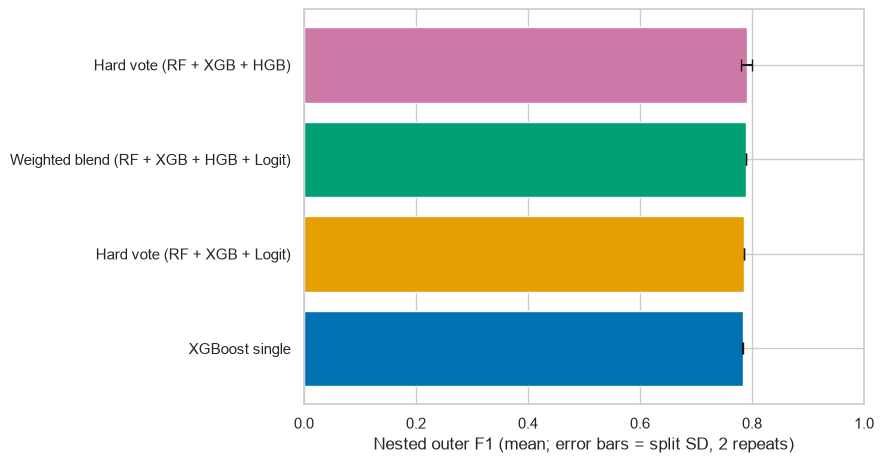

In [14]:
# 主比較図：nested CVを方式選定の主要根拠として表示します。
fig, axis = plt.subplots(figsize=(9, 4.8))
plot_data = nested_summary.sort_values("f1_mean")
axis.barh(
    plot_data["method"], plot_data["f1_mean"],
    xerr=plot_data["f1_split_sd"], color=OKABE_ITO[: len(plot_data)], capsize=4,
)
axis.set_xlim(0, 1)
axis.set_xlabel("Nested outer F1 (mean; error bars = split SD, 2 repeats)")
axis.set_ylabel("")
plt.tight_layout()
plt.show()

**図の解釈**

- **目的**：ハイパーパラメータ・しきい値選択から分離したouter予測で、提出方式を比較する。
- **観察**：hard votingが僅差で最上位、weighted blendが次点、XGBoost単体がその直後でした。
- **含意**：3枠はこの3方式へ割り当てます。ただし同一712人の2分割なので、誤差棒は独立試行の信頼区間ではなく分割感度です。

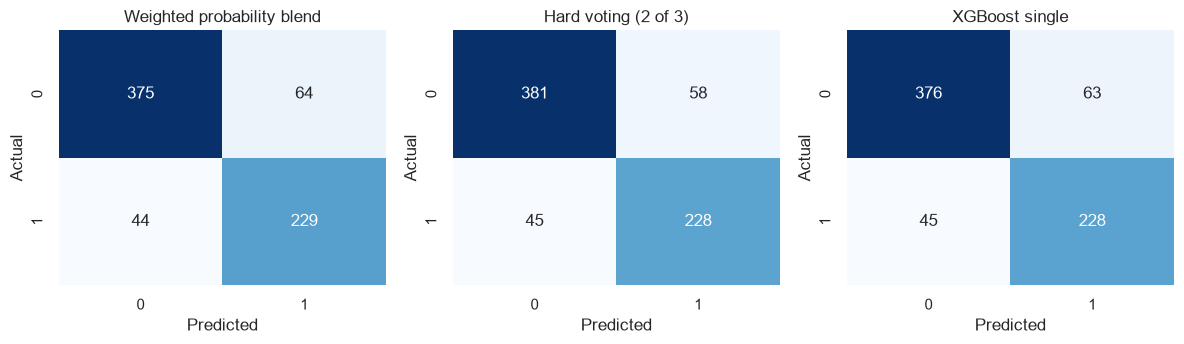

In [15]:
# 3方式の選択込みOOF混同行列です。
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for axis, method_name in zip(axes, ["weighted_blend", "hard_voting", "xgboost"]):
    matrix = confusion_matrix(y, method_prediction[method_name])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(METHOD_DISPLAY_NAMES[method_name])
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()

### 特徴量重要度

候補比較中に得たfold別重要度を、選ばれたRF・XGBoost設定だけで平均します。重要度は因果効果ではありません。

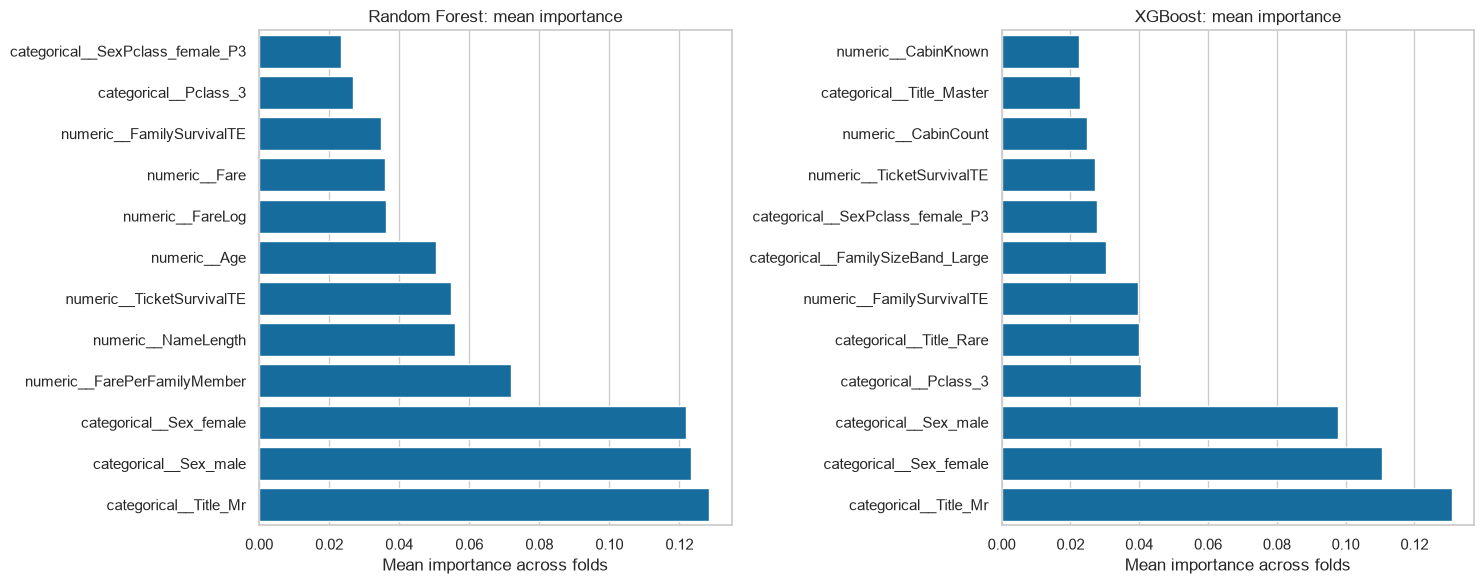

In [16]:
importance_table = pd.concat(importance_records, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, model_name in zip(axes, ["random_forest", "xgboost"]):
    selected_name = selected_configs[model_name]["name"]
    top = (
        importance_table.loc[
            (importance_table["model"] == model_name)
            & (importance_table["config"] == selected_name)
        ]
        .groupby("feature", as_index=False)["importance"].mean()
        .nlargest(12, "importance").sort_values("importance")
    )
    sns.barplot(data=top, x="importance", y="feature", ax=axis, color="#0072B2")
    axis.set_title(f"{MODEL_DISPLAY_NAMES[model_name]}: mean importance")
    axis.set_xlabel("Mean importance across folds")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()

## 10. AD内外の性能を検証する

5回中3回以上AD内なら、その乗客をAD内とします。AD内外それぞれでF1と乗客単位bootstrap 95%区間を表示します。区間は固定されたcross-fit予測に条件付きで、再学習の不確実性は含みません。

In [17]:
ad_inside = ad_inside_by_seed.sum(axis=0) >= 3
ad_ratio = np.median(ad_ratio_by_seed, axis=0)


def bootstrap_f1_interval(
    y_true: np.ndarray, prediction: np.ndarray, indices: np.ndarray,
    n_bootstrap: int = 3000, random_state: int = 20260711,
) -> tuple[float, float]:
    rng = np.random.default_rng(random_state)
    values = np.empty(n_bootstrap)
    for bootstrap_index in range(n_bootstrap):
        sampled = rng.choice(indices, size=len(indices), replace=True)
        values[bootstrap_index] = f1_score(
            y_true[sampled], prediction[sampled], zero_division=0
        )
    return tuple(np.percentile(values, [2.5, 97.5]))


region_rows = []
y_array = y.to_numpy()
for method_name, prediction in method_prediction.items():
    for region_name, mask in [("inside", ad_inside), ("outside", ~ad_inside)]:
        indices = np.flatnonzero(mask)
        low, high = bootstrap_f1_interval(y_array, prediction, indices)
        region_rows.append({
            "method": METHOD_DISPLAY_NAMES[method_name],
            "AD": region_name,
            "n": len(indices),
            "positive_n": int(y_array[indices].sum()),
            "precision": precision_score(y_array[indices], prediction[indices], zero_division=0),
            "recall": recall_score(y_array[indices], prediction[indices], zero_division=0),
            "f1": f1_score(y_array[indices], prediction[indices], zero_division=0),
            "bootstrap_95_low": low,
            "bootstrap_95_high": high,
        })
ad_region_table = pd.DataFrame(region_rows)
display(ad_region_table.round(4))

# 代表的なADルータ候補：AD内はXGB、AD外はRF。
rf_prediction = labels_from_probability(
    selected_oof_probability["random_forest"], individual_thresholds["random_forest"]
)
ad_route_prediction = np.where(
    ad_inside, method_prediction["xgboost"], rf_prediction
).astype("int64")
ad_route_summary = pd.DataFrame([
    {
        "method": "XGBoost single",
        "global_f1": f1_score(y, method_prediction["xgboost"]),
        "changed_rows_vs_xgb": 0,
    },
    {
        "method": "AD route: XGB inside / RF outside",
        "global_f1": f1_score(y, ad_route_prediction),
        "changed_rows_vs_xgb": int(
            (ad_route_prediction != method_prediction["xgboost"]).sum()
        ),
    },
])
print(f"OOF AD outside: {(~ad_inside).sum()} / {len(ad_inside)}")
display(ad_route_summary.round(4))

,method,AD,n,positive_n,precision,recall,f1,bootstrap_95_low,bootstrap_95_high
0,Weighted probability blend,inside,678,250,0.7782,0.8280,0.8023,0.7636,0.8392
1,Weighted probability blend,outside,34,23,0.8148,0.9565,0.8800,0.7692,0.9615
2,Hard voting (2 of 3),inside,678,250,0.7954,0.8240,0.8094,0.7702,0.8460
3,Hard voting (2 of 3),outside,34,23,0.8148,0.9565,0.8800,0.7692,0.9615
4,XGBoost single,inside,678,250,0.7833,0.8240,0.8031,0.7631,0.8410
5,XGBoost single,outside,34,23,0.7857,0.9565,0.8627,0.7442,0.9474


OOF AD outside: 34 / 712


,method,global_f1,changed_rows_vs_xgb
0,XGBoost single,0.8085,0
1,AD route: XGB inside / RF outside,0.8099,1


**ADの結論**

OOFではAD外が少数で、AD外のF1が低い傾向はありませんでした。XGBoostからRFへ切り替えても変更行が非常に少なく、改善の不確実性が大きいため、ADルータは提出しません。

これは「ADが無意味」という結論ではなく、**今回のAD定義とデータ分割では、3枠の1つを使う根拠が得られなかった**という限定的な判断です。ADはtestの予測を変える道具ではなく、適用範囲を診断する節として残します。

## 11. 全trainで再学習し、testを予測する

全設定を凍結した後、全712件でLOO特徴と前処理を学習します。選ばれた4モデルを5乱数で再学習し、test確率を平均します。

In [18]:
full_group_state = fit_group_state(base_train, y)
full_train_features = augment_train_loo(base_train, y, full_group_state)
full_test_features = augment_inference(base_test, full_group_state)

final_preprocessor = build_preprocessor()
transformed_full_train = final_preprocessor.fit_transform(
    full_train_features[MODEL_COLUMNS]
)
transformed_test = final_preprocessor.transform(full_test_features[MODEL_COLUMNS])
assert np.isfinite(transformed_full_train).all()
assert np.isfinite(transformed_test).all()

final_probability_by_seed = {
    model_name: np.zeros((len(CV_SEEDS), len(test)), dtype=float)
    for model_name in MODEL_CONFIGS
}
for seed_position, model_seed in enumerate(CV_SEEDS):
    for model_name, config in selected_configs.items():
        model = build_model(model_name, config, model_seed)
        model.fit(transformed_full_train, y)
        final_probability_by_seed[model_name][seed_position] = (
            model.predict_proba(transformed_test)[:, 1]
        )
    print(f"Final fit seed {model_seed}: 完了")

final_probability = {
    model_name: probabilities.mean(axis=0)
    for model_name, probabilities in final_probability_by_seed.items()
}
final_base_labels = {
    model_name: labels_from_probability(
        final_probability[model_name], individual_thresholds[model_name]
    )
    for model_name in MODEL_CONFIGS
}

final_hard_votes = sum(
    labels_from_probability(
        final_probability[model_name], hard_vote_choice["thresholds"][model_name]
    )
    for model_name in HARD_VOTE_MODELS
)
final_blend_probability = sum(
    blend_choice["weights"][model_name] * final_probability[model_name]
    for model_name in BLEND_MODEL_ORDER
)
final_submission_labels = {
    "weighted_blend": labels_from_probability(
        final_blend_probability, blend_choice["threshold"]
    ),
    "hard_voting": (final_hard_votes >= 2).astype("int64"),
    "xgboost": final_base_labels["xgboost"],
}
print("全件再学習と3方式のtest予測: OK")

Final fit seed 20260711: 完了
Final fit seed 20260712: 完了
Final fit seed 20260713: 完了
Final fit seed 20260714: 完了
Final fit seed 20260715: 完了
全件再学習と3方式のtest予測: OK


,test_rows,inside_AD,outside_AD,outside_rate
0,179,164,15,0.0838


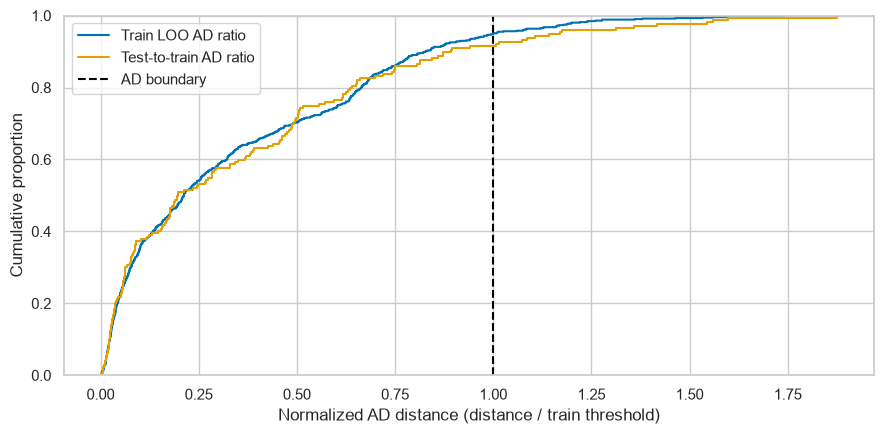

AD routeがXGBoostから変更するtest行数: 0


In [19]:
# 設定凍結後に、初めてtestのAD比率を診断表示します。
full_ad_state = fit_ad_state(base_train)
test_ad_score = score_ad(base_test, full_ad_state)
test_ad_ratio = test_ad_score / full_ad_state["threshold"]
test_inside_ad = test_ad_ratio <= 1.0
train_ad_ratio = full_ad_state["fit_scores"] / full_ad_state["threshold"]

# testをまとめて計算しても1行ずつ計算しても同じです。
recomputed_first_rows = np.array([
    score_ad(base_test.iloc[[row]], full_ad_state)[0]
    for row in range(min(10, len(base_test)))
])
assert np.allclose(test_ad_score[: len(recomputed_first_rows)], recomputed_first_rows)

ad_test_summary = pd.DataFrame([{
    "test_rows": len(test),
    "inside_AD": int(test_inside_ad.sum()),
    "outside_AD": int((~test_inside_ad).sum()),
    "outside_rate": float((~test_inside_ad).mean()),
}])
display(ad_test_summary)

fig, axis = plt.subplots(figsize=(9, 4.5))
sns.ecdfplot(train_ad_ratio, label="Train LOO AD ratio", ax=axis, color="#0072B2")
sns.ecdfplot(test_ad_ratio, label="Test-to-train AD ratio", ax=axis, color="#E69F00")
axis.axvline(1.0, color="black", linestyle="--", label="AD boundary")
axis.set_xlabel("Normalized AD distance (distance / train threshold)")
axis.set_ylabel("Cumulative proportion")
axis.legend()
plt.tight_layout()
plt.show()

# ADルータを提出しない判断を、最終test予測でも確認します。
final_ad_route = np.where(
    test_inside_ad, final_submission_labels["xgboost"],
    final_base_labels["random_forest"],
)
print(
    "AD routeがXGBoostから変更するtest行数:",
    int((final_ad_route != final_submission_labels["xgboost"]).sum()),
)

**図の解釈**

- **目的**：testがtrainの特徴空間からどの程度離れているかを、設定凍結後に確認する。
- **観察**：破線より右がAD外です。testの比率は診断結果であり、モデルやしきい値の再選択には使いません。
- **含意**：AD外率が高くても低くても、提出方式はtrain-only nested CVで決めた3方式のままです。

## 12. 3つの提出CSVを保存する

提出順はnested CVの順位に合わせます。

1. `submission_hard_voting.csv`
2. `submission_weighted_blend.csv`
3. `submission_xgboost.csv`

各CSVは `PassengerId,Survived` の2列、179行、testと同じID順、整数0/1です。

In [20]:
OUTPUT_FILES = {
    "weighted_blend": "submission_weighted_blend.csv",
    "hard_voting": "submission_hard_voting.csv",
    "xgboost": "submission_xgboost.csv",
}


def validate_submission(submission: pd.DataFrame, expected_ids: pd.Series) -> None:
    assert submission.columns.tolist() == ["PassengerId", "Survived"]
    assert submission.shape == (179, 2)
    assert submission.notna().all().all()
    assert submission["PassengerId"].is_unique
    assert np.array_equal(
        submission["PassengerId"].to_numpy(), expected_ids.to_numpy()
    )
    assert set(submission["PassengerId"]) == set(expected_ids)
    assert pd.api.types.is_integer_dtype(submission["Survived"])
    assert set(submission["Survived"].unique()).issubset({0, 1})


def save_submission(method_name: str) -> pd.DataFrame:
    submission = pd.DataFrame({
        "PassengerId": test["PassengerId"].astype("int64"),
        "Survived": final_submission_labels[method_name].astype("int64"),
    })
    validate_submission(submission, test["PassengerId"])
    output_path = PROJECT_DIR / OUTPUT_FILES[method_name]

    if output_path.exists():
        existing = pd.read_csv(output_path)
        validate_submission(existing, test["PassengerId"])
        if not existing.equals(submission):
            raise FileExistsError(
                f"既存ファイル {output_path.name} と新しい予測が異なります。"
                "上書きせず停止しました。"
            )
        print(f"{output_path.name}: 同一内容のため上書きを省略")
    else:
        submission.to_csv(output_path, index=False)
        print(f"{output_path.name}: 保存完了")

    reloaded = pd.read_csv(output_path)
    validate_submission(reloaded, test["PassengerId"])
    pd.testing.assert_frame_equal(submission, reloaded)
    return submission


submissions = {
    method_name: save_submission(method_name)
    for method_name in ["weighted_blend", "hard_voting", "xgboost"]
}
print("3つの提出CSVの保存後検査: OK")

submission_weighted_blend.csv: 同一内容のため上書きを省略
submission_hard_voting.csv: 同一内容のため上書きを省略
submission_xgboost.csv: 同一内容のため上書きを省略
3つの提出CSVの保存後検査: OK


In [21]:
submission_summary = []
for method_name in ["weighted_blend", "hard_voting", "xgboost"]:
    submission = submissions[method_name]
    submission_summary.append({
        "method": METHOD_DISPLAY_NAMES[method_name],
        "file": OUTPUT_FILES[method_name],
        "rows": len(submission),
        "unique_ids": submission["PassengerId"].nunique(),
        "predicted_survivors": int(submission["Survived"].sum()),
    })
    print(f"\n{OUTPUT_FILES[method_name]}")
    display(submission.head())

display(pd.DataFrame(submission_summary))


submission_weighted_blend.csv


,PassengerId,Survived
0,154,0
1,753,0
2,611,0
3,201,0
4,311,1



submission_hard_voting.csv


,PassengerId,Survived
0,154,0
1,753,0
2,611,0
3,201,0
4,311,1



submission_xgboost.csv


,PassengerId,Survived
0,154,0
1,753,0
2,611,0
3,201,0
4,311,1


,method,file,rows,unique_ids,predicted_survivors
0,Weighted probability blend,submission_weighted_blend.csv,179,179,69
1,Hard voting (2 of 3),submission_hard_voting.csv,179,179,68
2,XGBoost single,submission_xgboost.csv,179,179,69


## 13. よくある誤りと最終チェック

- testのAD外率を見てから提出方式や重みを変える
- trainとtestを結合して補完・カテゴリ・距離・Ticket人数を学習する
- CV前に全trainラベルでtarget encodingを作る
- hard votingの前に3モデルの確率を平均してしまう（これはsoft voting）
- foldやseedを独立標本として有意差を主張する

このNotebookでは、hard votingを3個の0/1票の多数決として実装し、ADはラベル非依存・batch-invariantです。提出は3件だけで、すべてモデル予測から自動生成します。

## 演習：hard votingとweighted blendを説明する

1. hard votingでは、各モデルのしきい値を変えると票がどう変わりますか。
2. weighted blendがhard votingより細かい情報を残すのはなぜですか。
3. AD外率を見てからモデルを変更することが、なぜ規約上危険なのでしょうか。

次のセルはOOF予測だけを使う回答用ひな型です。公式CSVは変更しません。

In [22]:
exercise_table = pd.DataFrame([
    {
        "method": METHOD_DISPLAY_NAMES[method_name],
        "OOF predicted positive": int(method_prediction[method_name].sum()),
        "OOF F1": f1_score(y, method_prediction[method_name]),
    }
    for method_name in ["weighted_blend", "hard_voting", "xgboost"]
])
display(exercise_table)

# TODO: 多数決と確率blendの違い、AD比率を事後利用しない理由を説明してみましょう。

,method,OOF predicted positive,OOF F1
0,Weighted probability blend,293,0.8092
1,Hard voting (2 of 3),286,0.8157
2,XGBoost single,291,0.8085


## まとめ

- 4 model family × 3設定を、同一の漏洩防止OOFで比較しました。
- nested CVを主要根拠に、3モデルhard voting、weighted blend、XGBoost単体を選びました。
- hard votingはRF・XGBoost・HistGradientBoostingの0/1票を2票以上で決定します。
- ADはGower風距離で診断しましたが、提出枠を使う性能根拠がなく不採用としました。
- testのAD比率は全設定凍結後にだけ表示しました。
- 3つのCSVは179行・2列・ID順一致・整数0/1を自動検査済みです。

「面白い手法を試すこと」と「検証で支持されない手法を提出しないこと」の両方が、再現可能なコンペ分析では重要です。